In [1]:
import numpy as np
import matplotlib.pyplot as plt
from src.ABM_package import Tau
from src.custom_functions import get_parameters_files

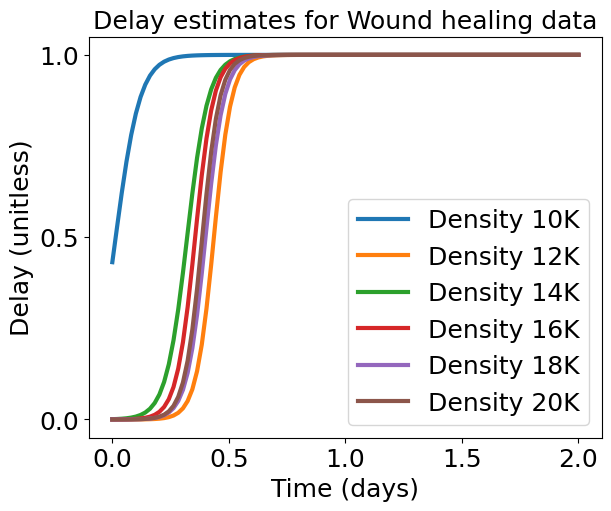

In [4]:
data_type = "WH"
pred_type = "fit_all"
parameter_names = "rm_pint_rp_a0_a1" 
densities = np.arange(6)
model_type = "PDE"
estimate_type = "mean"

t_fine = np.linspace(0,2,100)

fig,axes = plt.subplots(1,1,figsize=(6,5),layout="constrained")
fontsize=18

for dens_id in densities:

    input_parameters = [None, parameter_names, model_type, data_type, dens_id, pred_type]

    (parameter_names, 
    model_type, 
    data_type, 
    dens, 
    simulation,
    initial_perc,
    trueParams,
    delay, 
    lower_bounds,
    upper_bounds,
    indepParams,
    dxs,
    prediction_type,
    priorDir, 
    histogramDir, 
    posteriorDir) = get_parameters_files(input_parameters)

    mat = np.load(f"{posteriorDir}mean_info.npy",allow_pickle=True).item()
    estimate = mat[estimate_type]
    
    axes.plot(t_fine,Tau(t_fine,estimate[-2],estimate[-1]),
              "-",label=f"Density {dens}K", linewidth=3)


axes.legend(fontsize=fontsize)

plt.xlabel("Time (days)",fontsize=fontsize)
plt.ylabel("Delay (unitless)",fontsize=fontsize)
plt.title("Delay estimates for Wound healing data",fontsize=fontsize)

plt.xticks(np.linspace(0,2,5),np.linspace(0,2,5),fontsize=fontsize);
plt.yticks(np.linspace(0,1,3),np.linspace(0,1,3),fontsize=fontsize);

plt.savefig(f"../../results/Figures/WH_delayed_term_PDE_model_4.pdf",format="pdf")

In [5]:
%load_ext watermark

%watermark -n -u -v -iv -w

The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
Last updated: Fri Jun 05 2026

Python implementation: CPython
Python version       : 3.11.5
IPython version      : 8.15.0

matplotlib: 3.8.0
numpy     : 1.25.2

Watermark: 2.4.3

